In [29]:
def get_nc_info(PATH: str, temp_var: str | None = None):
    """Print a structured summary of a NetCDF file: variables, coords, grid, time, global attrs."""
    import xarray as xr
    import numpy as np
    
    TEMP_CANDIDATES = ["tas", "tair", "t2m", "TREFHT", "temp", "air",
                       "TS", "ts", "T2", "temperature"]
    LON_NAMES = ["lon", "longitude", "nav_lon", "x"]
    LAT_NAMES = ["lat", "latitude", "nav_lat", "y"]
    
    def first_match(names, container):
        return next((n for n in names if n in container), None)
    
    with xr.open_dataset(PATH, decode_times=False) as ds:
        print(f"=== FILE: {PATH} ===\n")
        
        # 1. Pick temperature variable(s)
        if temp_var is None:
            temp_vars = [v for v in ds.data_vars if v in TEMP_CANDIDATES]
            print(f"Likely temperature variable(s): {temp_vars}")
        elif temp_var in ds.data_vars:
            temp_vars = [temp_var]
            print(f"Using user-specified temperature variable: {temp_var}")
        else:
            print(f"⚠  '{temp_var}' not found. Available variables:")
            for v in ds.data_vars:
                print(f"    - {v}")
            return
        
        print(f"All data variables: {list(ds.data_vars)}\n")
        
        # 2. Variable details
        for v in temp_vars or list(ds.data_vars):
            da = ds[v]
            fill = da.attrs.get("_FillValue", da.encoding.get("_FillValue", "n/a"))
            print(f"--- {v} ---")
            print(f"  long_name : {da.attrs.get('long_name', 'n/a')}")
            print(f"  units     : {da.attrs.get('units', 'n/a')}   # K vs degC matters!")
            print(f"  dims      : {da.dims}")
            print(f"  shape     : {da.shape}")
            print(f"  dtype     : {da.dtype}")
            print(f"  _FillValue: {fill}\n")
        
        # 3. Coordinates
        print("--- Coordinates ---")
        for name, c in ds.coords.items():
            unit = c.attrs.get("units", "n/a")
            if np.issubdtype(c.dtype, np.number):
                print(f"  {name:12s} size={c.size:6d}  "
                      f"min={c.values.min()}  max={c.values.max()}  units={unit}")
            else:
                print(f"  {name:12s} size={c.size:6d}  units={unit}")
        
        # 4. Grid summary
        lon_name = first_match(LON_NAMES, ds.coords)
        lat_name = first_match(LAT_NAMES, ds.coords)
        if lon_name:
            conv = "0..360" if float(ds[lon_name].max()) > 180 else "-180..180"
            print(f"\n  Longitude convention: {conv}")
        if lat_name and lon_name:
            grid = "regular 1D" if ds[lat_name].ndim == 1 else "2D / curvilinear"
            print(f"  Grid type: {grid}")
            if ds[lat_name].ndim == 1 and ds[lat_name].size > 1:
                dlat = float(np.abs(np.diff(ds[lat_name].values)).mean())
                dlon = float(np.abs(np.diff(ds[lon_name].values)).mean())
                print(f"  Resolution: {dlat:.3f}° lat × {dlon:.3f}° lon")
        
        # 5. Time (paleo files often use "years since present")
        if "time" in ds.coords:
            t = ds["time"]
            t_units = t.attrs.get("units", "n/a")
            print(f"\n--- Time (raw, not auto-decoded) ---")
            print(f"  units    : {t_units}")
            print(f"  dtype    : {t.dtype}")
            print(f"  n_steps  : {t.size}")
            print(f"  range    : {t.values.min()}  →  {t.values.max()}")
            print(f"  step     : {np.diff(t.values)[:3]} ... (first 3 differences)")
            if "year" in t_units.lower():
                print(f"  → interpreted as years BP (Before Present, present=1950)")
                print(f"  → time span: {abs(t.values.min())} to {abs(t.values.max())} years BP")
        
        # 6. Global attrs
        print("\n--- Global attrs ---")
        for k, v in ds.attrs.items():
            print(f"  {k}: {v}")

In [30]:
from pathlib import Path

beyer2020_air = str(Path.cwd() / "data" / "Beyer2020" / "data" / "LateQuaternary_Environment.nc")
palmod2_air = str(Path.cwd() / "data" / "PalMod2" / "output" / "PMMXMCRTDGr111Amtasgn30201_1-250.nc")
palmod2_soil = str(Path.cwd() / "data" / "PalMod2" / "output" / "PMMXMCRTDGr111Lmtslgn30201_1-250.nc")
trace_air = str(Path.cwd() / "data" / "TraCE-21k" / "data" / "trace.01-36.22000BP.clm2.TSA.22000BP_decavg_400BCE.nc")
trace_soil = str(Path.cwd() / "data" / "TraCE-21k" / "data" / "trace.01-36.22000BP.clm2.TSOI.22000BP_decavg_400BCE.nc")
chelsa_air = str(Path.cwd() / "data" / "CHELSA-TraCE21k-centennial" / "output" / "tasmean.nc")


In [79]:
import pandas as pd

df_air = pd.DataFrame(columns=["name", "path", "variable", "unit"])
df_air.loc[0] = ["Beyer2020", beyer2020_air, "temperature", "degC"]
df_air.loc[1] = ["PalMod2", palmod2_air, "tas", "K"]
df_air.loc[2] = ["TraCE-21k", trace_air, "TSA", "K"]
df_air.loc[3] = ["CHELSA-TraCE21k-centennial", chelsa_air, "tasmean", "K"]

df_air

,name,path,variable,unit
0,Beyer2020,/home/lghomeoffice/git/paleoclimate_model_comp...,temperature,degC
1,PalMod2,/home/lghomeoffice/git/paleoclimate_model_comp...,tas,K
2,TraCE-21k,/home/lghomeoffice/git/paleoclimate_model_comp...,TSA,K
3,CHELSA-TraCE21k-centennial,/home/lghomeoffice/git/paleoclimate_model_comp...,tasmean,K


In [83]:
df_soil = pd.DataFrame(columns=["name", "path", "variable", "unit"])
df_soil.loc[0] = ["PalMod2", palmod2_soil, "tsl", "K"]
df_soil.loc[1] = ["TraCE-21k", trace_soil, "TSOI", "K"]

df_soil

,name,path,variable,unit
0,PalMod2,/home/lghomeoffice/git/paleoclimate_model_comp...,tsl,K
1,TraCE-21k,/home/lghomeoffice/git/paleoclimate_model_comp...,TSOI,K


In [82]:
#get_nc_info(trace_soil, "TSOI")

In [39]:
def plot_temperature_at_point(
    PATH: str,
    temp_var: str,
    lat: float,
    lon: float,
    input_unit: str = "degC",         # NEW: "degC" or "K"
    label: str | None = None,
):
    """Plot the temperature time series at a single point from a paleoclimate NetCDF file.
    Returns the annual-mean DataArray for the selected grid cell, in °C."""
    import xarray as xr
    import numpy as np
    import matplotlib.pyplot as plt

    # Validate up front so a typo fails loudly, not silently
    if input_unit not in ("degC", "K"):
        raise ValueError(f"input_unit must be 'degC' or 'K', got {input_unit!r}")

    LAT_NAMES = ["lat", "latitude", "nav_lat", "y"]
    LON_NAMES = ["lon", "longitude", "nav_lon", "x"]

    with xr.open_dataset(PATH, decode_times=False) as ds:
        lat_name = next((n for n in LAT_NAMES if n in ds.coords), None)
        lon_name = next((n for n in LON_NAMES if n in ds.coords), None)
        if lat_name is None or lon_name is None:
            raise KeyError(f"Could not find lat/lon coords in {list(ds.coords)}")

        if float(ds[lon_name].max()) > 180 and lon < 0:
            lon = lon + 360

        da = ds[temp_var].sel({lat_name: lat, lon_name: lon}, method="nearest")
        cell_lat = float(da[lat_name])
        cell_lon = float(da[lon_name])

        if "month" in da.dims:
            da = da.mean(dim="month")

        # Convert to °C if needed (K → °C is just an offset)
        if input_unit == "K":
            da = da - 273.15
            da.attrs["units"] = "degC"

        time_ka = -ds["time"].values / 1000
        y = da.values.copy()

    title = label or f"{temp_var} at ({cell_lat:.2f}°N, {cell_lon:.2f}°E)"
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.plot(time_ka, y, lw=1.6)
    ax.invert_xaxis()
    ax.axhline(0, color="k", lw=0.5, ls="--", alpha=0.5)
    ax.set_xlabel("Time (ka BP)")
    ax.set_ylabel(f"{temp_var} (°C)")
    ax.set_title(title)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return da

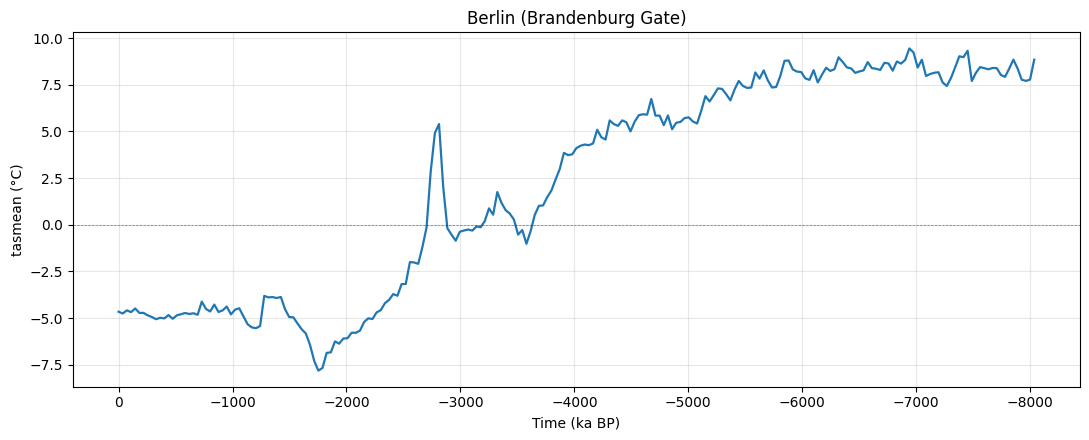

In [69]:
da = plot_temperature_at_point(
    PATH=chelsa_air,
    temp_var="tasmean",
    input_unit= "K",
    lat=52.5244,
    lon=13.4105,
    label="Berlin (Brandenburg Gate)",
)